# ECB supervisory banking indicators

This notebook uses the ECB Data Portal API to retrieve Supervisory Banking Statistics for significant institutions in the Single Supervisory Mechanism. It compares the SSM aggregate with the cross-country distribution, using the minimum, median and maximum across available SSM countries, and includes a configurable country focus.

In [1]:
# %pip install -r requirements.txt

## Data and method

The data are downloaded from the ECB `SUP` dataset through the SDMX web service in CSV format. For each selected indicator, the notebook retrieves all available reference areas, separates the SSM aggregate (`B01`) from country observations, and calculates the country-level minimum, median and maximum for each quarter.

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

API_BASE = "https://data-api.ecb.europa.eu/service/data/SUP"
START_PERIOD = "2015-Q2"
COUNTRY_FOCUS = "IT"

INDICATORS = {
    "CET1 ratio": "I4008",
    "Total capital ratio": "I4001",
    "Leverage ratio": "KSV12",
    "NPL ratio, excluding cash balances": "I7005",
    "Stage 2 loans ratio": "I7500",
    "Return on equity": "I2003",
    "Cost-to-income ratio": "I2100",
    "Liquidity coverage ratio": "I3017",
    "Net stable funding ratio": "I3214",
}

COUNTRY_NAMES = {
    "AT": "Austria", "BE": "Belgium", "BG": "Bulgaria", "CY": "Cyprus",
    "DE": "Germany", "EE": "Estonia", "ES": "Spain", "FI": "Finland",
    "FR": "France", "GR": "Greece", "HR": "Croatia", "IE": "Ireland",
    "IT": "Italy", "LT": "Lithuania", "LU": "Luxembourg", "LV": "Latvia",
    "MT": "Malta", "NL": "Netherlands", "PT": "Portugal", "SI": "Slovenia",
    "SK": "Slovakia", "B01": "SSM aggregate",
}

def ecb_sup_key(item_code: str, ref_area: str = "") -> str:
    """Build a SUP series key for significant institutions, percentage series."""
    return f"Q.{ref_area}.W0._Z.{item_code}._T.SII._Z._Z._Z.PCT.C"

def fetch_ecb_sup_indicator(label: str, item_code: str) -> pd.DataFrame:
    url = f"{API_BASE}/{ecb_sup_key(item_code)}"
    params = {
        "startPeriod": START_PERIOD,
        "format": "csvdata",
    }
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()

    df = pd.read_csv(StringIO(response.text))
    if df.empty:
        raise RuntimeError(f"No data returned for {label} ({item_code}).")

    out = df[["REF_AREA", "TIME_PERIOD", "OBS_VALUE", "TITLE"]].copy()
    out["date"] = pd.PeriodIndex(out["TIME_PERIOD"], freq="Q").to_timestamp(how="end").normalize()
    out["value"] = pd.to_numeric(out["OBS_VALUE"], errors="coerce")
    out["indicator"] = label
    out["item_code"] = item_code
    out["area_name"] = out["REF_AREA"].map(COUNTRY_NAMES).fillna(out["REF_AREA"])
    return out[["date", "TIME_PERIOD", "REF_AREA", "area_name", "indicator", "item_code", "value", "TITLE"]]

series = pd.concat(
    [fetch_ecb_sup_indicator(label, code) for label, code in INDICATORS.items()],
    ignore_index=True,
)

aggregate = series[series["REF_AREA"] == "B01"].copy()
country_series = series[series["REF_AREA"] != "B01"].dropna(subset=["value"]).copy()

country_distribution = (
    country_series
    .groupby(["indicator", "date", "TIME_PERIOD"], as_index=False)
    .agg(
        country_min=("value", "min"),
        country_median=("value", "median"),
        country_max=("value", "max"),
        country_count=("REF_AREA", "nunique"),
    )
)

country_focus = country_series[country_series["REF_AREA"] == COUNTRY_FOCUS].copy()

def latest_distribution_summary() -> pd.DataFrame:
    rows = []
    for indicator, group in country_series.groupby("indicator"):
        latest_date = group["date"].max()
        current = group[group["date"] == latest_date].copy()
        current = current.dropna(subset=["value"])
        if current.empty:
            continue

        min_row = current.loc[current["value"].idxmin()]
        max_row = current.loc[current["value"].idxmax()]
        median_value = current["value"].median()

        agg_match = aggregate[(aggregate["indicator"] == indicator) & (aggregate["date"] == latest_date)]
        focus_match = current[current["REF_AREA"] == COUNTRY_FOCUS]

        rows.append({
            "indicator": indicator,
            "latest_period": current["TIME_PERIOD"].iloc[0],
            "countries": current["REF_AREA"].nunique(),
            "min_country": min_row["area_name"],
            "min_pct": min_row["value"],
            "median_pct": median_value,
            "max_country": max_row["area_name"],
            "max_pct": max_row["value"],
            f"{COUNTRY_FOCUS}_pct": focus_match["value"].iloc[0] if not focus_match.empty else pd.NA,
            "ssm_aggregate_pct": agg_match["value"].iloc[0] if not agg_match.empty else pd.NA,
        })

    out = pd.DataFrame(rows).sort_values("indicator")
    numeric_cols = [c for c in out.columns if c.endswith("_pct")]
    out[numeric_cols] = out[numeric_cols].round(2)
    return out

latest_summary = latest_distribution_summary()

print(f"Country focus: {COUNTRY_NAMES.get(COUNTRY_FOCUS, COUNTRY_FOCUS)} ({COUNTRY_FOCUS})")
print("Latest available ECB supervisory banking indicators")
print(latest_summary.to_string(index=False))


Country focus: Italy (IT)
Latest available ECB supervisory banking indicators
                         indicator latest_period  countries min_country  min_pct  median_pct max_country  max_pct  IT_pct  ssm_aggregate_pct
                        CET1 ratio       2025-Q4         15       Spain    13.29       18.13      Latvia    22.05   15.85              16.18
              Cost-to-income ratio       2025-Q4         15    Portugal    36.08       50.59      France    66.56   50.36              54.95
                    Leverage ratio       2025-Q4         15       Spain     5.49        6.49    Slovenia    10.16    6.16               5.95
          Liquidity coverage ratio       2025-Q4         14      France   142.60      169.76   Lithuania   351.24  169.20             158.60
NPL ratio, excluding cash balances       2025-Q4         15      Latvia     0.55        1.85      Greece     2.85    2.15               2.18
          Net stable funding ratio       2025-Q4         14      France   11

## Latest values

The table below reports the latest available country distribution for each indicator. It shows the cross-country minimum, median and maximum, the corresponding countries for the minimum and maximum, the selected country focus and the SSM aggregate.

In [3]:
latest_summary

                         indicator latest_period  countries min_country  min_pct  median_pct max_country  max_pct  IT_pct  ssm_aggregate_pct
                        CET1 ratio       2025-Q4         15       Spain    13.29       18.13      Latvia    22.05   15.85              16.18
              Cost-to-income ratio       2025-Q4         15    Portugal    36.08       50.59      France    66.56   50.36              54.95
                    Leverage ratio       2025-Q4         15       Spain     5.49        6.49    Slovenia    10.16    6.16               5.95
          Liquidity coverage ratio       2025-Q4         14      France   142.60      169.76   Lithuania   351.24  169.20             158.60
NPL ratio, excluding cash balances       2025-Q4         15      Latvia     0.55        1.85      Greece     2.85    2.15               2.18
          Net stable funding ratio       2025-Q4         14      France   114.99      136.44   Lithuania   203.30  130.97             126.49
             

## Country focus against the cross-country range

Each chart shows the cross-country min-max range, the cross-country median, the selected focus country and the SSM aggregate. This makes it easier to see whether the focus country is close to the centre of the distribution or closer to the tails.

In [4]:
def plot_indicator_focus(indicator: str, title: str | None = None):
    dist = country_distribution[country_distribution["indicator"] == indicator].sort_values("date")
    agg = aggregate[aggregate["indicator"] == indicator].sort_values("date")
    focus = country_focus[country_focus["indicator"] == indicator].sort_values("date")

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.fill_between(
        dist["date"],
        dist["country_min"],
        dist["country_max"],
        color="#d8e2dc",
        alpha=0.9,
        label="Country min-max range",
    )
    ax.plot(dist["date"], dist["country_median"], color="#1b4332", linewidth=2.2, label="Country median")
    ax.plot(agg["date"], agg["value"], color="#264653", linewidth=2.1, linestyle="--", label="SSM aggregate")

    if not focus.empty:
        ax.plot(
            focus["date"],
            focus["value"],
            color="#d62828",
            linewidth=2.3,
            label=f"{COUNTRY_NAMES.get(COUNTRY_FOCUS, COUNTRY_FOCUS)}",
        )

    ax.set_title(title or indicator)
    ax.set_ylabel("Percent")
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    fig.text(
        0.01,
        0.01,
        "Source: ECB Data Portal, Supervisory Banking Statistics (SUP). Significant institutions; changing sample.",
        ha="left",
        fontsize=8,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()


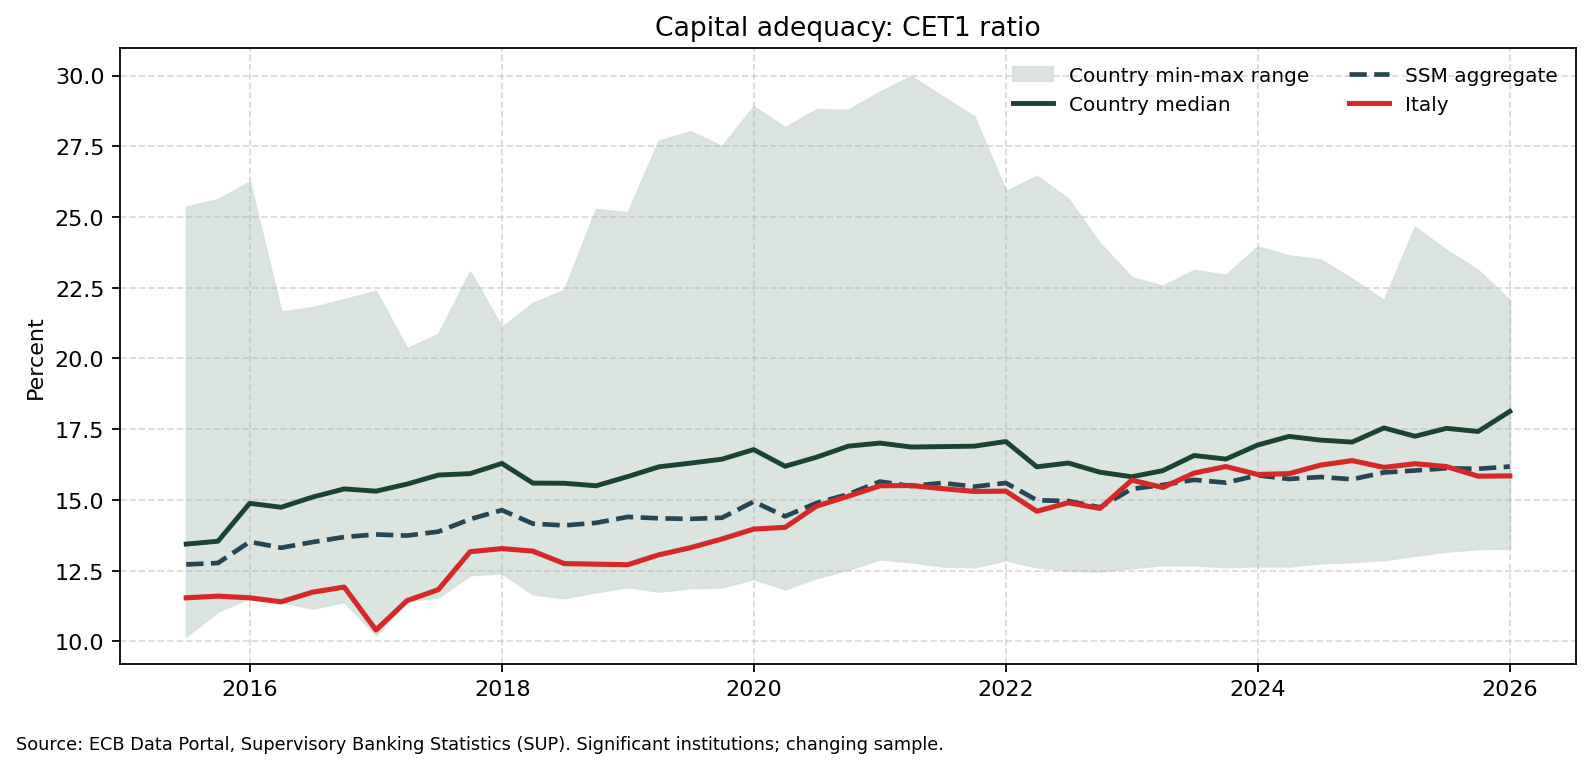

In [5]:
plot_indicator_focus("CET1 ratio", "Capital adequacy: CET1 ratio")

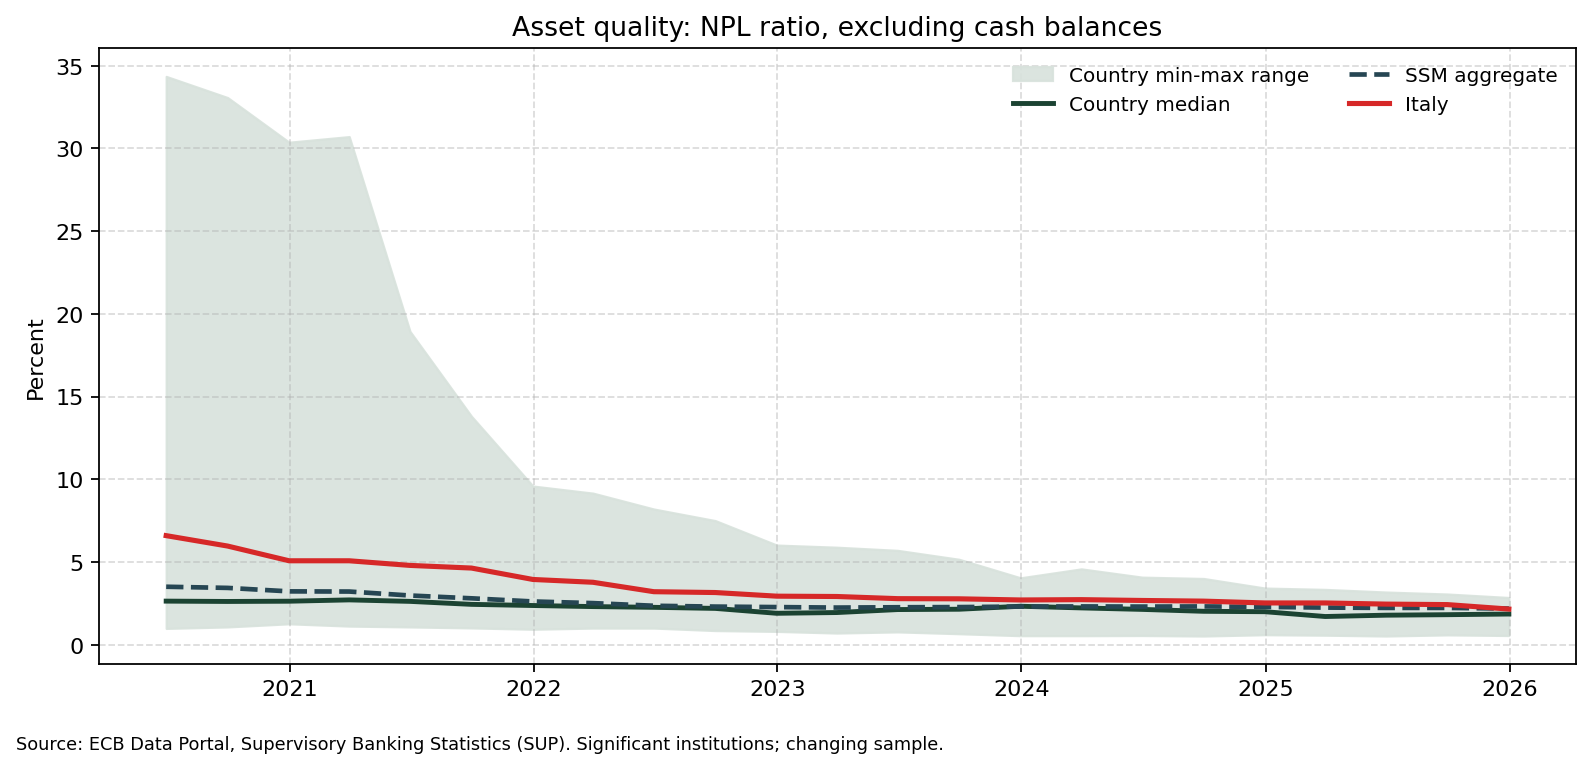

In [6]:
plot_indicator_focus("NPL ratio, excluding cash balances", "Asset quality: NPL ratio, excluding cash balances")

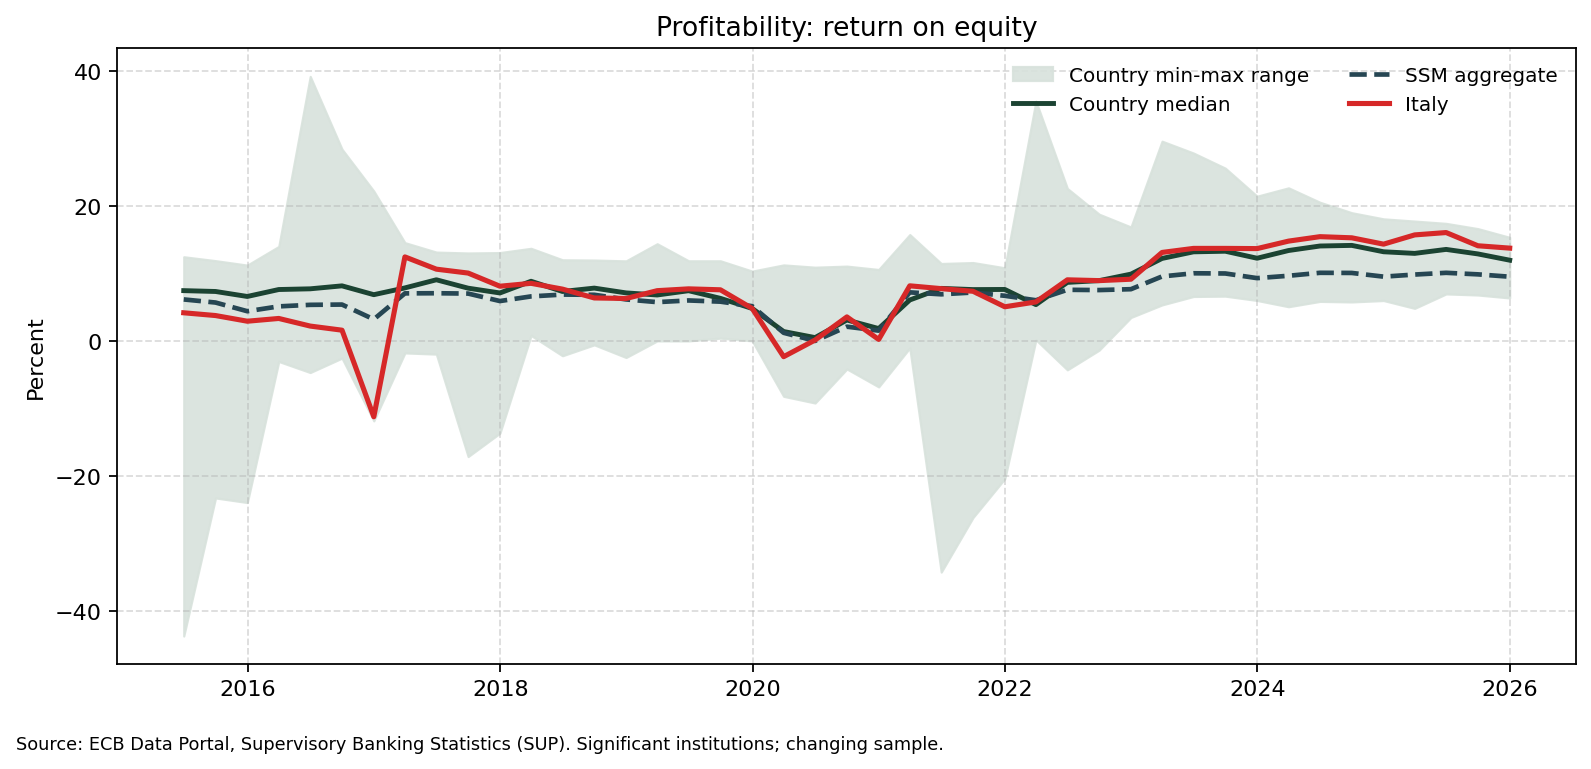

In [7]:
plot_indicator_focus("Return on equity", "Profitability: return on equity")

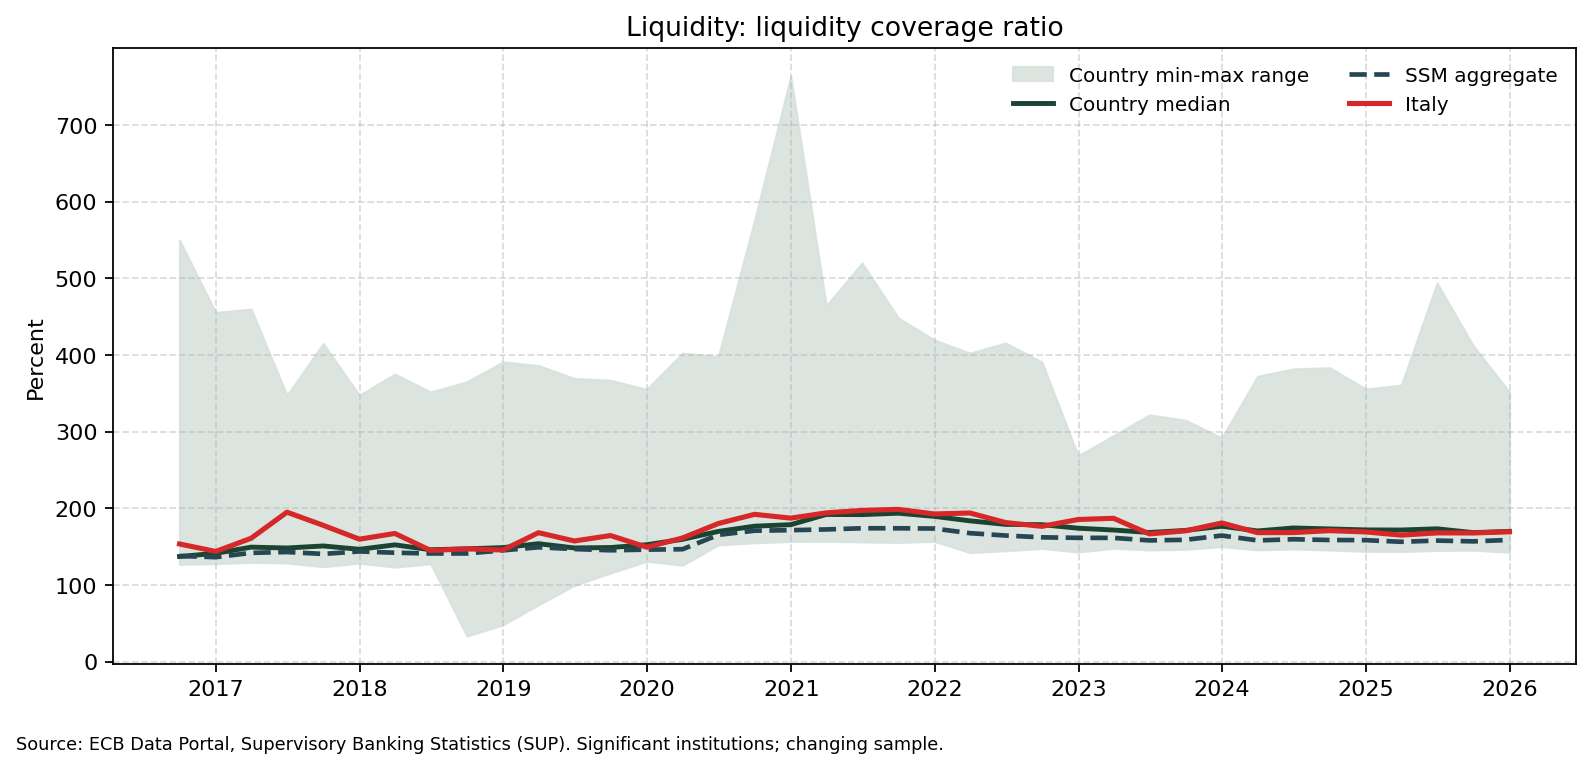

In [8]:
plot_indicator_focus("Liquidity coverage ratio", "Liquidity: liquidity coverage ratio")

## Latest country focus snapshot

The final chart compares the selected focus country with the SSM aggregate and the cross-country median for the latest available quarter of each indicator.

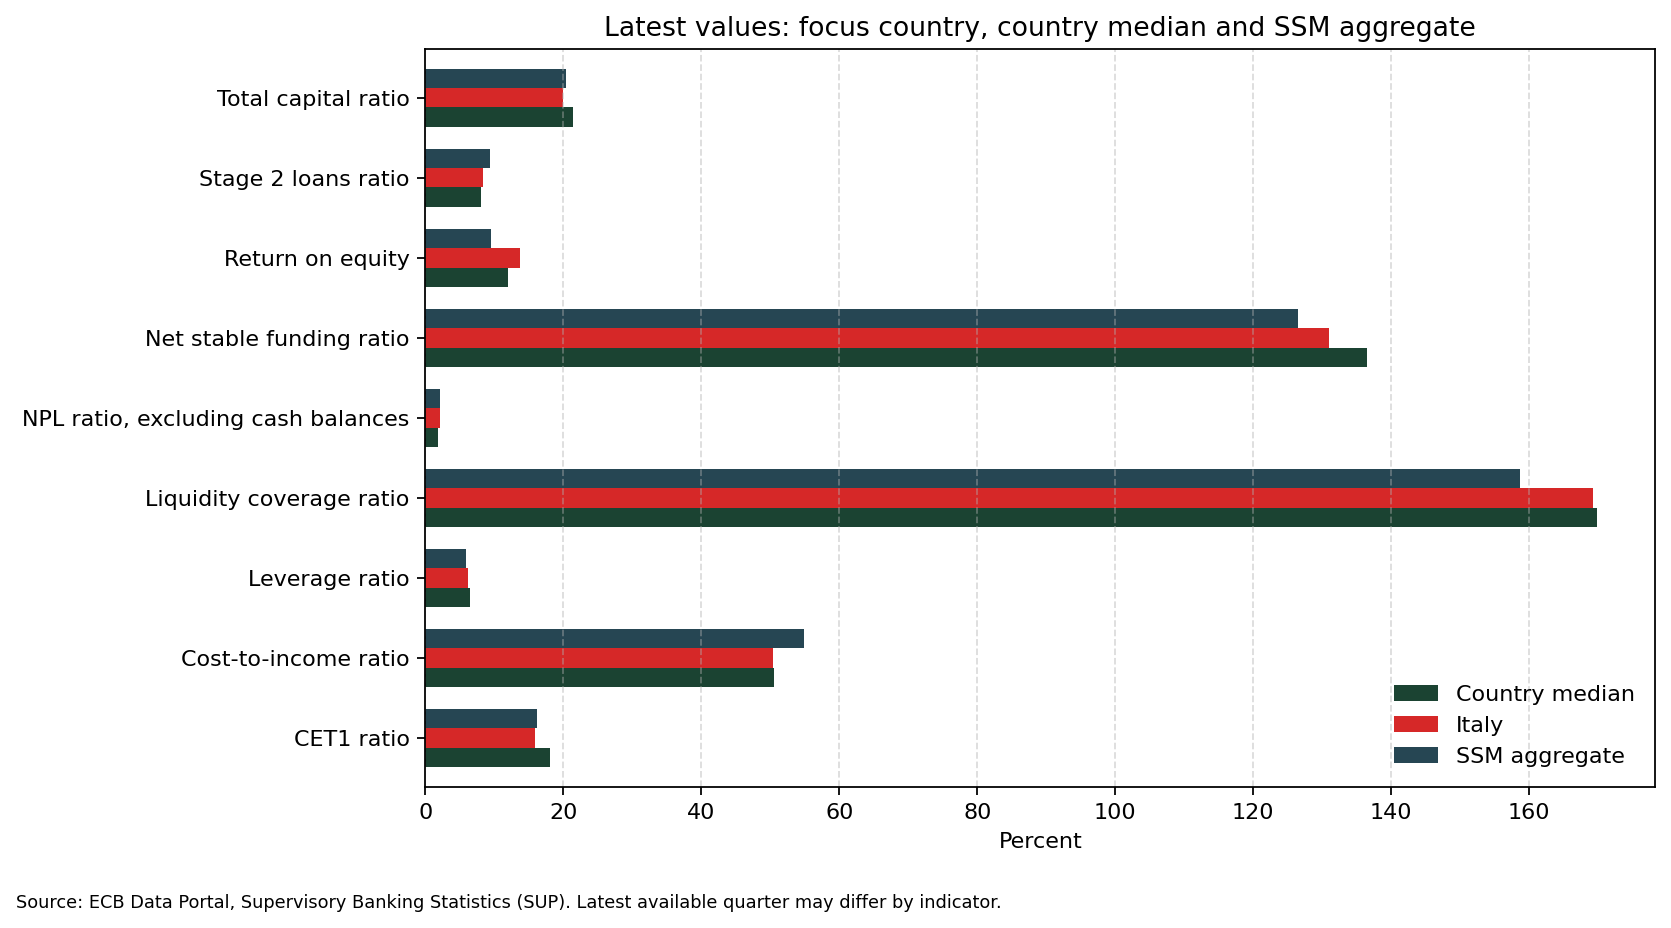

In [9]:
snapshot = latest_summary.copy()
focus_col = f"{COUNTRY_FOCUS}_pct"
plot_df = snapshot[["indicator", "median_pct", focus_col, "ssm_aggregate_pct"]].copy()
plot_df = plot_df.rename(columns={
    "median_pct": "Country median",
    focus_col: COUNTRY_NAMES.get(COUNTRY_FOCUS, COUNTRY_FOCUS),
    "ssm_aggregate_pct": "SSM aggregate",
})
plot_df = plot_df.set_index("indicator")

fig, ax = plt.subplots(figsize=(10.5, 5.8))
plot_df.plot(kind="barh", ax=ax, width=0.72, color=["#1b4332", "#d62828", "#264653"])
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.set_title("Latest values: focus country, country median and SSM aggregate")
ax.grid(axis="x", linestyle="--", alpha=0.45)
ax.legend(frameon=False, loc="lower right")
fig.text(
    0.01,
    0.01,
    "Source: ECB Data Portal, Supervisory Banking Statistics (SUP). Latest available quarter may differ by indicator.",
    ha="left",
    fontsize=8,
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()
